<a href="https://colab.research.google.com/github/farrelrassya/PracticalLinearAlgebra/blob/main/06_Chapter_06_Matrices_pt2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 6: Matrices, Part 2
## *Practical Linear Algebra for Data Science* — Mike X Cohen

Chapter 5 covered the mechanics of matrices: creation, arithmetic, multiplication, transpose. This chapter introduces the concepts that elevate matrices from simple spreadsheets to the powerful structures that underpin data science: **norms**, **spaces**, **rank**, and the **determinant**.

$$
\underbrace{\text{Norms}}_{\text{How "big" is a matrix?}}
\;\longrightarrow\;
\underbrace{\text{Spaces}}_{\text{What can a matrix reach?}}
\;\longrightarrow\;
\underbrace{\text{Rank}}_{\text{How much information?}}
\;\longrightarrow\;
\underbrace{\text{Determinant}}_{\text{Is it invertible?}}
\;\longrightarrow\;
\underbrace{\text{Char. Poly.}}_{\text{What are the eigenvalues?}}
$$

Each concept builds on the previous one, and together they provide the foundation for the matrix inverse (Chapter 8), eigendecomposition (Chapter 13), and SVD (Chapter 14).

## 0. Setup

In [7]:
import numpy as np
import scipy.linalg
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

plt.rcParams.update({
    'figure.figsize': (7, 5),
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 12
})

np.random.seed(42)
print('NumPy version:', np.__version__)
print('SciPy version:', scipy.__version__)
print('Setup complete.')

NumPy version: 2.0.2
SciPy version: 1.16.3
Setup complete.


Environment ready. We use SciPy for the `null_space` function.

## 1. Matrix Norms

A **matrix norm** is a single number that characterises the "size" of a matrix. There are two broad families:

- **Element-wise norms:** Computed from individual matrix entries. They reflect the magnitudes of the elements.
- **Induced norms:** Reflect how much the matrix stretches vectors during matrix-vector multiplication (covered fully in Chapter 14 with the SVD).

### 1.1 The Frobenius Norm

The most common element-wise norm is the **Frobenius norm** (also called the Euclidean norm or $\ell_2$ norm), which generalises the vector norm to matrices:

$$
\|\mathbf{A}\|_F = \sqrt{\sum_{i=1}^{M} \sum_{j=1}^{N} a_{i,j}^2}
$$

It is simply the square root of the sum of all squared elements -- treating the matrix as a long vector. The general $p$-norm is:

$$
\|\mathbf{A}\|_p = \left( \sum_{i=1}^{M} \sum_{j=1}^{N} |a_{i,j}|^p \right)^{1/p}
$$

Setting $p = 2$ recovers the Frobenius norm; $p = 1$ gives the $\ell_1$ norm (sum of absolute values).

In [8]:
# Frobenius norm: manual vs NumPy
A = np.array([[1, 2, 3],
              [4, 5, 6]])

# Manual
frob_manual = np.sqrt(np.sum(A**2))

# NumPy (default 'fro' for matrices)
frob_numpy = np.linalg.norm(A, 'fro')

# Also equivalent: treating matrix as a 1D vector
frob_flat = np.linalg.norm(A.flatten())

print(f'Matrix A:')
print(A)
print(f'\nFrobenius norm (manual):  {frob_manual:.6f}')
print(f'Frobenius norm (NumPy):   {frob_numpy:.6f}')
print(f'Frobenius norm (flatten): {frob_flat:.6f}')

# L1 norm (element-wise)
l1_norm = np.sum(np.abs(A))
print(f'\nElement-wise L1 norm: {l1_norm}')
print(f'Sum of squared elements: {np.sum(A**2)}')

Matrix A:
[[1 2 3]
 [4 5 6]]

Frobenius norm (manual):  9.539392
Frobenius norm (NumPy):   9.539392
Frobenius norm (flatten): 9.539392

Element-wise L1 norm: 21
Sum of squared elements: 91


All three methods agree: $\|\mathbf{A}\|_F = \sqrt{1^2 + 2^2 + 3^2 + 4^2 + 5^2 + 6^2} = \sqrt{91} \approx 9.5394$.

**Applications of matrix norms in data science:**

- **Regularisation:** $\ell_2$ regularisation (ridge regression) adds $\lambda\|\mathbf{W}\|_F^2$ to the loss function, penalising large weights and preventing overfitting. $\ell_1$ regularisation (lasso) adds $\|\mathbf{W}\|_1$, encouraging sparsity.
- **Matrix distance:** The Frobenius distance between two matrices $\|\mathbf{A} - \mathbf{B}\|_F$ measures how "different" they are. This is the objective minimised in low-rank matrix approximation and image compression.

### 1.2 Matrix Trace

The **trace** of a square matrix is the sum of its diagonal elements:

$$
\text{tr}(\mathbf{A}) = \sum_{i=1}^{M} a_{i,i}
$$

A beautiful connection: the Frobenius norm can be computed via the trace:

$$
\|\mathbf{A}\|_F = \sqrt{\text{tr}(\mathbf{A}^T\mathbf{A})}
$$

This works because each diagonal element of $\mathbf{A}^T\mathbf{A}$ is the dot product of a column of $\mathbf{A}$ with itself (i.e., the sum of squares of that column).

In [9]:
# Trace examples from the textbook
M1 = np.array([[4, 5, 6], [0, 1, 4], [9, 9, 9]])
M2 = np.array([[0, 0, 0], [0, 8, 0], [1, 2, 6]])

print(f'M1 =\n{M1}')
print(f'tr(M1) = {np.trace(M1)}\n')
print(f'M2 =\n{M2}')
print(f'tr(M2) = {np.trace(M2)}\n')

# Frobenius norm via trace
A = np.array([[1, 2, 3], [4, 5, 6]])
frob_trace = np.sqrt(np.trace(A.T @ A))
frob_direct = np.linalg.norm(A, 'fro')
print(f'Frobenius norm via trace:  {frob_trace:.6f}')
print(f'Frobenius norm directly:   {frob_direct:.6f}')
print(f'Match: {np.isclose(frob_trace, frob_direct)}')

M1 =
[[4 5 6]
 [0 1 4]
 [9 9 9]]
tr(M1) = 14

M2 =
[[0 0 0]
 [0 8 0]
 [1 2 6]]
tr(M2) = 14

Frobenius norm via trace:  9.539392
Frobenius norm directly:   9.539392
Match: True


Both textbook matrices have trace $14$: for $\mathbf{M}_1$, $4 + 1 + 9 = 14$; for $\mathbf{M}_2$, $0 + 8 + 6 = 14$. Very different matrices, same trace -- the trace captures only the diagonal, not the full structure.

The trace-Frobenius connection is verified: $\sqrt{\text{tr}(\mathbf{A}^T\mathbf{A})} = \|\mathbf{A}\|_F \approx 9.5394$.

**Additional trace properties:** $\text{tr}(\mathbf{A}) = \sum \lambda_i$ (the trace equals the sum of eigenvalues, Chapter 13) and $\text{tr}(\mathbf{A}\mathbf{B}) = \text{tr}(\mathbf{B}\mathbf{A})$ (cyclic property, used in gradient derivations).

## 2. Matrix Spaces

Every matrix defines four fundamental subspaces. These are nothing more than the infinite sets of vectors reachable via linear weighted combinations of the matrix's features (columns, rows, or their complements).

### 2.1 Column Space

The **column space** $\mathcal{C}(\mathbf{A})$ is the set of all vectors that can be expressed as a linear combination of the columns of $\mathbf{A}$:

$$
\mathcal{C}(\mathbf{A}) = \{\mathbf{b} \;|\; \mathbf{b} = \mathbf{A}\mathbf{x} \text{ for some } \mathbf{x} \in \mathbb{R}^N\}
$$

Equivalently: $\mathbf{b} \in \mathcal{C}(\mathbf{A})$ means $\mathbf{b}$ is reachable from the columns of $\mathbf{A}$.

In [10]:
# Example 1: one column -> 1D column space (a line)
A1 = np.array([[1], [3]])
print(f'A1 = {A1.flatten()}  (one column in R^2)')
print(f'Column space: a line through origin in direction [1, 3]')

# Is [1, 3] in C(A1)? lambda=1 -> yes
# Is [-2, -6] in C(A1)? lambda=-2 -> yes
# Is [1, 4] in C(A1)? No scalar works
tests = [([1, 3], True), ([-2, -6], True), ([1, 4], False)]
for v, expected in tests:
    v = np.array(v)
    # Check: can we find lambda such that lambda*A1[:,0] = v?
    if np.allclose(A1[:, 0] * (v[0] / A1[0, 0]), v):
        lam = v[0] / A1[0, 0]
        status = f'YES (lambda={lam})'
    else:
        status = 'NO'
    print(f'  {v} in C(A1)? {status}')

A1 = [1 3]  (one column in R^2)
Column space: a line through origin in direction [1, 3]
  [1 3] in C(A1)? YES (lambda=1.0)
  [-2 -6] in C(A1)? YES (lambda=-2.0)
  [1 4] in C(A1)? NO


The matrix $\mathbf{A}_1 = [1, 3]^T$ has a 1D column space: the line $\lambda[1, 3]^T$ through the origin. Vectors $[1, 3]$ ($\lambda=1$) and $[-2, -6]$ ($\lambda=-2$) lie on this line. But $[1, 4]$ does not -- no scalar $\lambda$ can simultaneously satisfy $\lambda \cdot 1 = 1$ and $\lambda \cdot 3 = 4$.

In [11]:
# Example 2: two independent columns in R^2 -> column space = all of R^2
A2 = np.array([[1, 1],
               [3, 2]])

# Example 3: two DEPENDENT columns in R^2 -> column space = 1D line
A3 = np.array([[1, 2],
               [3, 6]])

print(f'A2 (independent columns):')
print(A2)
print(f'Rank: {np.linalg.matrix_rank(A2)}  -> column space = all of R^2\n')

print(f'A3 (dependent columns, col2 = 2*col1):')
print(A3)
print(f'Rank: {np.linalg.matrix_rank(A3)}  -> column space = 1D line')

# Verify: can we reach [-4, 3] with A2?
b = np.array([-4, 3])
x = np.linalg.solve(A2, b)
print(f'\nReach b = {b} via A2: x = {x}')
print(f'Verify: A2 @ x = {A2 @ x}')

A2 (independent columns):
[[1 1]
 [3 2]]
Rank: 2  -> column space = all of R^2

A3 (dependent columns, col2 = 2*col1):
[[1 2]
 [3 6]]
Rank: 1  -> column space = 1D line

Reach b = [-4  3] via A2: x = [ 11. -15.]
Verify: A2 @ x = [-4.  3.]


Two linearly independent columns in $\mathbb{R}^2$ span all of $\mathbb{R}^2$ -- any vector is reachable. For $\mathbf{b} = [-4, 3]^T$, the weights are $\mathbf{x} = [11, -15]^T$ (matching the textbook).

Two dependent columns ($\mathbf{A}_3$, where column 2 $= 2 \times$ column 1) span only a 1D line. Having $N$ columns does *not* guarantee an $N$-dimensional column space -- the dimensionality equals the number of **independent** columns, which is the **rank**.

### 2.2 Column Space: 2D Plane in $\mathbb{R}^3$

A4 =
[[3 0]
 [5 2]
 [1 2]]
Rank: 2
Column space: 2D plane in R^3


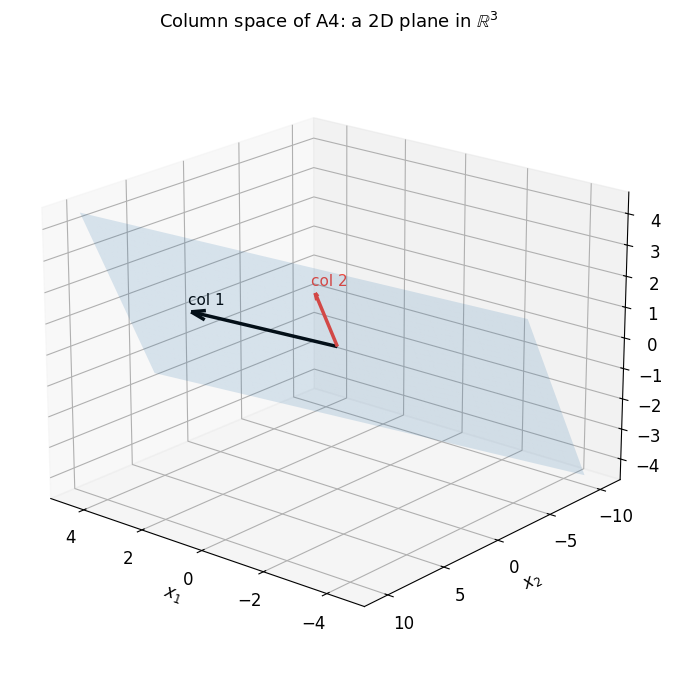

Figure saved.


In [12]:
# Two independent columns in R^3 -> 2D plane
A4 = np.array([[3, 0],
               [5, 2],
               [1, 2]])

print(f'A4 =\n{A4}')
print(f'Rank: {np.linalg.matrix_rank(A4)}')
print(f'Column space: 2D plane in R^3')

fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection='3d')

# Plot the 2D plane spanned by the two columns
c1, c2 = A4[:, 0], A4[:, 1]
s = np.linspace(-1.5, 1.5, 30)
S1, S2 = np.meshgrid(s, s)
X = S1 * c1[0] + S2 * c2[0]
Y = S1 * c1[1] + S2 * c2[1]
Z = S1 * c1[2] + S2 * c2[2]
ax.plot_surface(X, Y, Z, alpha=0.15, color='#2196F3')

# Plot column vectors
ax.quiver(0, 0, 0, *c1, color='k', arrow_length_ratio=0.1, lw=2.5)
ax.quiver(0, 0, 0, *c2, color='#F44336', arrow_length_ratio=0.1, lw=2.5)
ax.text(c1[0]+0.1, c1[1], c1[2]+0.2, 'col 1', fontsize=11)
ax.text(c2[0]+0.1, c2[1]+0.1, c2[2]+0.2, 'col 2', fontsize=11, color='#F44336')

ax.set_xlabel('$x_1$'); ax.set_ylabel('$x_2$'); ax.set_zlabel('$x_3$')
ax.set_title('Column space of A4: a 2D plane in $\\mathbb{R}^3$', fontsize=13)
ax.view_init(elev=20, azim=130)
plt.tight_layout()
plt.savefig('fig_colspace_3d.png', dpi=100, bbox_inches='tight')
plt.show()
print('Figure saved.')

The $3 \times 2$ matrix $\mathbf{A}_4$ has two independent columns in $\mathbb{R}^3$. Its column space is a **2D plane** embedded in 3D (the translucent blue surface). Vectors on this plane are reachable via $\mathbf{A}_4\mathbf{x}$; vectors off the plane are not.

**This is the central question of linear algebra:** Given a matrix $\mathbf{A}$ and a vector $\mathbf{b}$, is $\mathbf{b} \in \mathcal{C}(\mathbf{A})$? If yes, there exists an exact solution $\mathbf{x}$ to $\mathbf{A}\mathbf{x} = \mathbf{b}$. If not, we seek the *closest* reachable vector -- this is the **least squares** solution (Chapter 11).

### 2.3 Row Space

The **row space** $\mathcal{R}(\mathbf{A})$ is the set of all linear combinations of the *rows* of $\mathbf{A}$. Since transposing swaps rows and columns:

$$
\mathcal{R}(\mathbf{A}) = \mathcal{C}(\mathbf{A}^T)
$$

The **dimensionality** of the row space equals the dimensionality of the column space (both equal the rank), even for nonsquare matrices. However, the row space and column space live in *different* ambient spaces: for an $M \times N$ matrix, the column space is in $\mathbb{R}^M$ and the row space is in $\mathbb{R}^N$.

In [13]:
# Textbook example: 2x3 matrix, rank 2
A = np.array([[1, 1, -4],
              [2, -2, 2]])

r = np.linalg.matrix_rank(A)
print(f'A =\n{A}')
print(f'Shape: {A.shape}')
print(f'Rank: {r}')
print(f'\nColumn space: {r}D in R^{A.shape[0]}')
print(f'Row space:    {r}D in R^{A.shape[1]}')
print(f'Dimensionality of both spaces: {r} (same, always!)')

A =
[[ 1  1 -4]
 [ 2 -2  2]]
Shape: (2, 3)
Rank: 2

Column space: 2D in R^2
Row space:    2D in R^3
Dimensionality of both spaces: 2 (same, always!)


The $2 \times 3$ matrix has rank $2$. Its column space is $2$D in $\mathbb{R}^2$ (the entire plane), and its row space is a $2$D plane in $\mathbb{R}^3$. Different spaces, but the same dimensionality. This equality is a fundamental theorem of linear algebra.

### 2.4 Null Space

The **null space** $\mathcal{N}(\mathbf{A})$ is the set of all vectors $\mathbf{y}$ satisfying:

$$
\mathbf{A}\mathbf{y} = \mathbf{0}
$$

These are the "invisible" directions -- vectors that the matrix maps to zero. The trivial solution $\mathbf{y} = \mathbf{0}$ is excluded.

**Key relationship:** The null space is nontrivial (nonempty) if and only if the matrix is **rank-deficient** (has dependent columns). Full-rank matrices have an empty null space.

In [14]:
# Textbook example 1: rank-deficient -> nontrivial null space
A = np.array([[1, -1],
              [-2, 2]])

# Textbook example 2: full rank -> empty null space
B = np.array([[1, -1],
              [-2, 3]])

ns_A = scipy.linalg.null_space(A)
ns_B = scipy.linalg.null_space(B)

print(f'A (rank-deficient):')
print(A)
print(f'Rank: {np.linalg.matrix_rank(A)}')
print(f'Null space: {ns_A.flatten()}')
print(f'Norm of null space vector: {np.linalg.norm(ns_A):.6f} (unit vector!)')
print(f'Verify: A @ ns = {(A @ ns_A).flatten()} (should be zeros)')

print(f'\nB (full rank):')
print(B)
print(f'Rank: {np.linalg.matrix_rank(B)}')
print(f'Null space: {ns_B.flatten()} (empty!)')

A (rank-deficient):
[[ 1 -1]
 [-2  2]]
Rank: 1
Null space: [0.70710678 0.70710678]
Norm of null space vector: 1.000000 (unit vector!)
Verify: A @ ns = [0. 0.] (should be zeros)

B (full rank):
[[ 1 -1]
 [-2  3]]
Rank: 2
Null space: [] (empty!)


Matrix $\mathbf{A} = \begin{bmatrix} 1 & -1 \\ -2 & 2 \end{bmatrix}$ has rank $1$ (column 2 $= -1 \times$ column 1). Its null space is $\mathcal{N}(\mathbf{A}) = \lambda [0.7071, 0.7071]^T$, which is $\lambda [1, 1]^T$ normalised to unit length. Verification: $\mathbf{A} \cdot [0.7071, 0.7071]^T = [0, 0]^T$.

Matrix $\mathbf{B}$ has rank $2$ (full rank). Its columns are independent, so no nontrivial $\mathbf{y}$ can produce $\mathbf{0}$ -- the null space is the **empty set** $\{\}$.

**Why null spaces matter:**
- **Eigenvectors** (Chapter 13): The eigenvalue equation $(\mathbf{A} - \lambda\mathbf{I})\mathbf{v} = \mathbf{0}$ asks for the null space of the shifted matrix.
- **Least squares** (Chapter 11): Null space components add arbitrarily to solutions without affecting the fit.
- **Under-determined systems**: When $\mathbf{A}$ has more columns than rows, the null space contains the degrees of freedom in the solution.

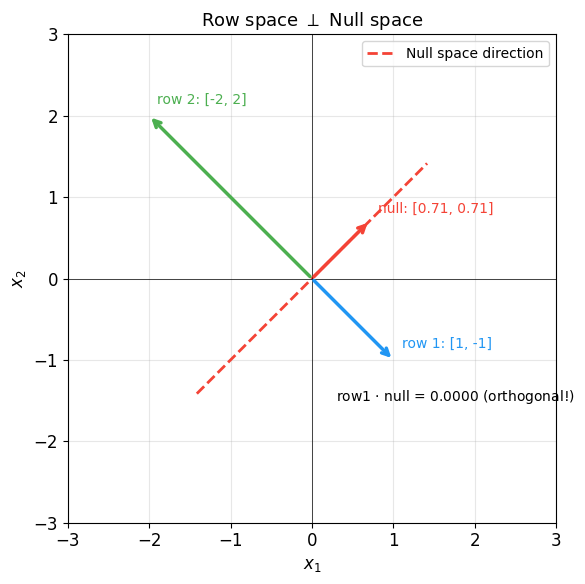

Figure saved.


In [15]:
# Visualise: row space is orthogonal to null space
A = np.array([[1, -1], [-2, 2]])
ns = scipy.linalg.null_space(A).flatten()

fig, ax = plt.subplots(figsize=(7, 6))

# Row vectors
for i, (c, label) in enumerate(zip(['#2196F3', '#4CAF50'],
                                    ['row 1: [1, -1]', 'row 2: [-2, 2]'])):
    row = A[i, :]
    ax.annotate('', xy=row, xytext=(0, 0),
                arrowprops=dict(arrowstyle='->', color=c, lw=2.5))
    ax.text(row[0]+0.1, row[1]+0.15, label, fontsize=10, color=c)

# Null space direction
ns_scaled = ns * 2
ax.plot([-ns_scaled[0], ns_scaled[0]], [-ns_scaled[1], ns_scaled[1]],
        '--', color='#F44336', lw=2, label='Null space direction')
ax.annotate('', xy=ns, xytext=(0, 0),
            arrowprops=dict(arrowstyle='->', color='#F44336', lw=2.5))
ax.text(ns[0]+0.1, ns[1]+0.1, f'null: [{ns[0]:.2f}, {ns[1]:.2f}]',
        fontsize=10, color='#F44336')

# Show orthogonality
dot_r1_ns = np.dot(A[0, :], ns)
ax.text(0.3, -1.5, f'row1 $\cdot$ null = {dot_r1_ns:.4f} (orthogonal!)',
        fontsize=10)

ax.set_xlim(-3, 3)
ax.set_ylim(-3, 3)
ax.set_aspect('equal')
ax.axhline(0, color='k', lw=0.5)
ax.axvline(0, color='k', lw=0.5)
ax.set_xlabel('$x_1$'); ax.set_ylabel('$x_2$')
ax.set_title('Row space $\\perp$ Null space', fontsize=13)
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('fig_null_space.png', dpi=100, bbox_inches='tight')
plt.show()
print('Figure saved.')

The row vectors (blue and green) are collinear (row 2 $= -2 \times$ row 1), spanning a 1D row space. The null space vector (red) is **orthogonal** to both rows: $\text{row}_1 \cdot \text{null} = 1 \cdot 0.707 + (-1) \cdot 0.707 = 0$.

This orthogonality is built into the definition: $\mathbf{A}\mathbf{y} = \mathbf{0}$ means each row's dot product with $\mathbf{y}$ is zero, so $\mathbf{y}$ is perpendicular to every row.

**The four fundamental subspaces** of an $M \times N$ matrix:

| Subspace | Symbol | Lives in | Dimension |
|----------|--------|----------|-----------|
| Column space | $\mathcal{C}(\mathbf{A})$ | $\mathbb{R}^M$ | $r$ |
| Row space | $\mathcal{R}(\mathbf{A}) = \mathcal{C}(\mathbf{A}^T)$ | $\mathbb{R}^N$ | $r$ |
| Null space | $\mathcal{N}(\mathbf{A})$ | $\mathbb{R}^N$ | $N - r$ |
| Left null space | $\mathcal{N}(\mathbf{A}^T)$ | $\mathbb{R}^M$ | $M - r$ |

where $r = \text{rank}(\mathbf{A})$. The dimensions add up: $r + (N - r) = N$ and $r + (M - r) = M$.

## 3. Matrix Rank

**Rank** is a nonnegative integer that quantifies how much *independent information* a matrix contains.

### Key Properties

- $\text{rank}(\mathbf{A}) \in \{0, 1, 2, \ldots\}$ (always a nonnegative integer)
- Maximum possible rank: $\min(M, N)$
- **Full-rank**: $r = \min(M, N)$. **Rank-deficient** (singular): $r < \min(M, N)$
- $\text{rank}(\alpha \mathbf{A}) = \text{rank}(\mathbf{A})$ for $\alpha \neq 0$

### Equivalent Definitions

- Largest number of columns (or rows) forming a linearly independent set
- Dimensionality of the column space (= dimensionality of the row space)
- Number of nonzero singular values

In [16]:
# Textbook rank examples
matrices = {
    'A (vector)': np.array([[1, 2, 4]]),
    'B (dependent cols)': np.array([[1, 3], [2, 6], [4, 12]]),
    'C (nearly dep.)': np.array([[1, 3.1], [2, 6], [4, 12]]),
    'D (3x3)': np.array([[1, 3, 2], [6, 6, 1], [4, 2, 0]]),
    'E (all ones)': np.ones((3, 3)),
    'F (all zeros)': np.zeros((3, 3)),
}

print(f'{"Matrix":>20s} {"Shape":>8s} {"Rank":>5s} {"max(rank)":>10s} {"Status":>12s}')
print('-' * 60)
for name, M in matrices.items():
    r = np.linalg.matrix_rank(M)
    max_r = min(M.shape)
    status = 'FULL' if r == max_r else 'DEFICIENT'
    print(f'{name:>20s} {str(M.shape):>8s} {r:>5d} {max_r:>10d} {status:>12s}')

              Matrix    Shape  Rank  max(rank)       Status
------------------------------------------------------------
          A (vector)   (1, 3)     1          1         FULL
  B (dependent cols)   (3, 2)     1          2    DEFICIENT
     C (nearly dep.)   (3, 2)     2          2         FULL
             D (3x3)   (3, 3)     3          3         FULL
        E (all ones)   (3, 3)     1          3    DEFICIENT
       F (all zeros)   (3, 3)     0          3    DEFICIENT


The results match the textbook:

- **A** (a row vector): rank $1$ -- all vectors have rank $1$ (except the zero vector).
- **B**: rank $1$ -- column 2 is exactly $3 \times$ column 1.
- **C**: rank $2$ -- changing just one element ($3 \to 3.1$) breaks the dependency.
- **D**: rank $3$ -- full rank for a $3 \times 3$ matrix with no column dependencies.
- **E** (all ones): rank $1$ -- every row (and column) is identical.
- **F** (all zeros): rank $0$ -- the only matrix with rank zero.

**The difference between B and C is striking:** changing a single element from $3.0$ to $3.1$ doubles the rank from $1$ to $2$. This illustrates why rank is fragile in practice and why NumPy uses a tolerance when computing it.

### 3.1 Ranks of Special Matrices

In [17]:
np.random.seed(42)

# Identity
I5 = np.eye(5)
print(f'Identity I_5: rank = {np.linalg.matrix_rank(I5)}')

# Diagonal with some zeros
D = np.diag([3, 0, 7, 0, 2])
print(f'Diagonal [3,0,7,0,2]: rank = {np.linalg.matrix_rank(D)} '
      f'(= {np.count_nonzero(np.diag(D))} nonzero diag elements)')

# Triangular with all nonzero diag
T = np.triu(np.random.randn(4, 4))
print(f'Upper triangular (4x4), diag = {np.round(np.diag(T), 2)}: '
      f'rank = {np.linalg.matrix_rank(T)}')

# Random Gaussian -> always full rank
R = np.random.randn(5, 3)
print(f'Random Gaussian (5x3): rank = {np.linalg.matrix_rank(R)} '
      f'(= min(5,3) = full rank!)')

# Rank-1 via outer product
u = np.array([4, 2, 3])
v = np.array([3, 1, 1, 3, 1])
R1 = np.outer(u, v)
print(f'\nRank-1 matrix (outer product):')
print(R1)
print(f'Rank: {np.linalg.matrix_rank(R1)}')

Identity I_5: rank = 5
Diagonal [3,0,7,0,2]: rank = 3 (= 3 nonzero diag elements)
Upper triangular (4x4), diag = [ 0.5  -0.23 -0.46 -0.56]: rank = 4
Random Gaussian (5x3): rank = 3 (= min(5,3) = full rank!)

Rank-1 matrix (outer product):
[[12  4  4 12  4]
 [ 6  2  2  6  2]
 [ 9  3  3  9  3]]
Rank: 1


Summary of special matrix ranks:

| Matrix type | Rank |
|-------------|------|
| $\mathbf{I}_N$ | $N$ |
| Diagonal | Number of nonzero diagonal elements |
| Triangular (nonzero diag) | Full rank |
| Random Gaussian | $\min(M, N)$ (with probability $\approx 1$) |
| Outer product $\mathbf{u}\mathbf{v}^T$ | $1$ (if $\mathbf{u}, \mathbf{v} \neq \mathbf{0}$) |
| $\mathbf{0}$ | $0$ |

The rank-1 matrix from the outer product of $[4, 2, 3]^T$ and $[3, 1, 1, 3, 1]$ confirms every row is a scalar multiple of every other row, and every column is a scalar multiple of every other column.

### 3.2 Rank of Sums and Products

$$
\text{rank}(\mathbf{A} + \mathbf{B}) \leq \text{rank}(\mathbf{A}) + \text{rank}(\mathbf{B})
$$
$$
\text{rank}(\mathbf{A}\mathbf{B}) \leq \min\big(\text{rank}(\mathbf{A}),\; \text{rank}(\mathbf{B})\big)
$$

These are **upper bounds**, not equalities. You cannot determine the exact rank from the individual ranks alone.

In [18]:
# Rank of sum can EXCEED individual ranks
np.random.seed(42)
# Two rank-1 matrices whose sum is rank-2
a1, b1 = np.array([[1], [0]]), np.array([[1, 0]])
a2, b2 = np.array([[0], [1]]), np.array([[0, 1]])
R1 = a1 @ b1  # rank 1
R2 = a2 @ b2  # rank 1
S = R1 + R2    # rank 2 = identity!

print(f'R1 (rank-1):\n{R1}')
print(f'R2 (rank-1):\n{R2}')
print(f'R1 + R2 (rank {np.linalg.matrix_rank(S)}):\n{S}')
print(f'  rank(sum) = {np.linalg.matrix_rank(S)} > max(rank(R1), rank(R2)) = 1')

# Rank of product cannot exceed individual ranks
A = np.random.randn(4, 3)  # rank 3
B = np.random.randn(3, 5)  # rank 3
AB = A @ B
print(f'\nA ({A.shape}): rank {np.linalg.matrix_rank(A)}')
print(f'B ({B.shape}): rank {np.linalg.matrix_rank(B)}')
print(f'AB ({AB.shape}): rank {np.linalg.matrix_rank(AB)}'
      f'  <= min({np.linalg.matrix_rank(A)}, {np.linalg.matrix_rank(B)}) = {min(np.linalg.matrix_rank(A), np.linalg.matrix_rank(B))}')

R1 (rank-1):
[[1 0]
 [0 0]]
R2 (rank-1):
[[0 0]
 [0 1]]
R1 + R2 (rank 2):
[[1 0]
 [0 1]]
  rank(sum) = 2 > max(rank(R1), rank(R2)) = 1

A ((4, 3)): rank 3
B ((3, 5)): rank 3
AB ((4, 5)): rank 3  <= min(3, 3) = 3


The sum of two rank-$1$ matrices can be rank-$2$ (here the sum is the identity matrix). But the product's rank is bounded by the minimum of the individual ranks -- multiplication cannot *create* new independent directions.

**Production insight:** In neural networks, a layer with weight matrix $\mathbf{W} \in \mathbb{R}^{m \times n}$ can output at most $\min(m, n)$ independent dimensions. LoRA (Low-Rank Adaptation) exploits this by factoring $\mathbf{W} = \mathbf{B}\mathbf{A}$ where $\mathbf{B} \in \mathbb{R}^{m \times r}$ and $\mathbf{A} \in \mathbb{R}^{r \times n}$ with $r \ll \min(m,n)$, achieving efficient fine-tuning.

### 3.3 Shifting Restores Full Rank

In [19]:
# Textbook example: rank-2 matrix shifted to rank-3
A = np.array([[1, 3, 2],
              [5, 7, 2],
              [2, 2, 0]])

lam = 0.01
A_shifted = A + lam * np.eye(3)

print(f'A =\n{A}')
print(f'Rank(A) = {np.linalg.matrix_rank(A)}')
print(f'Note: col3 = col2 - col1: {np.array_equal(A[:,2], A[:,1] - A[:,0])}')

print(f'\nA + {lam}*I =')
print(A_shifted)
print(f'Rank(A + {lam}*I) = {np.linalg.matrix_rank(A_shifted)}')

# Correlation between original and shifted
rho = np.corrcoef(A.flatten(), A_shifted.flatten())[0, 1]
print(f'\nCorrelation(original, shifted) = {rho:.15f}')

A =
[[1 3 2]
 [5 7 2]
 [2 2 0]]
Rank(A) = 2
Note: col3 = col2 - col1: True

A + 0.01*I =
[[1.01 3.   2.  ]
 [5.   7.01 2.  ]
 [2.   2.   0.01]]
Rank(A + 0.01*I) = 3

Correlation(original, shifted) = 0.999997222233797


The original matrix has rank $2$ because column $3$ equals column $2$ minus column $1$. After shifting by just $\lambda = 0.01$, the rank jumps to $3$ (full rank). Yet the information is barely changed: the Pearson correlation between original and shifted elements is $\rho \approx 0.99999972$.

This has profound practical implications:
- A rank-$2$ matrix **cannot be inverted** (it is singular).
- The shifted matrix **can be inverted** (it is full rank).
- The shift barely changes the information content.

This is the mathematical basis of **ridge regression** ($\ell_2$ regularisation): adding $\lambda\mathbf{I}$ to the singular $\mathbf{X}^T\mathbf{X}$ matrix makes it invertible while preserving most of its information.

## 4. The Determinant

The **determinant** is a single number associated with a **square** matrix. Its two most important properties:

1. Defined **only** for square matrices
2. Equals **zero** for singular (rank-deficient) matrices; nonzero for full-rank matrices

### 4.1 The 2x2 Formula

$$
\det\begin{pmatrix} a & b \\ c & d \end{pmatrix} = ad - bc
$$

Diagonal product minus off-diagonal product. For larger matrices, computation becomes rapidly more complex ($O(N!)$ terms for an $N \times N$ matrix).

In [20]:
# 2x2 determinant: manual and NumPy
A = np.array([[3, 7], [1, 4]])
det_manual = A[0,0]*A[1,1] - A[0,1]*A[1,0]
det_numpy = np.linalg.det(A)

print(f'A = {A.tolist()}')
print(f'det(A) = {A[0,0]}*{A[1,1]} - {A[0,1]}*{A[1,0]} = {det_manual}')
print(f'np.linalg.det(A) = {det_numpy:.1f}')

# Singular matrix -> det = 0
S = np.array([[2, 4], [1, 2]])
print(f'\nSingular S = {S.tolist()}')
print(f'det(S) = {S[0,0]*S[1,1]} - {S[0,1]*S[1,0]} = {S[0,0]*S[1,1] - S[0,1]*S[1,0]}')

# 3x3 determinant
B = np.array([[1, 2, 3], [4, 5, 6], [7, 8, 0]])
print(f'\n3x3 matrix B:')
print(B)
print(f'det(B) = {np.linalg.det(B):.1f}')
print(f'rank(B) = {np.linalg.matrix_rank(B)} (full rank, so det != 0)')

A = [[3, 7], [1, 4]]
det(A) = 3*4 - 7*1 = 5
np.linalg.det(A) = 5.0

Singular S = [[2, 4], [1, 2]]
det(S) = 4 - 4 = 0

3x3 matrix B:
[[1 2 3]
 [4 5 6]
 [7 8 0]]
det(B) = 27.0
rank(B) = 3 (full rank, so det != 0)


For the $2 \times 2$ case: $\det(\mathbf{A}) = 3 \cdot 4 - 7 \cdot 1 = 5$ (nonzero, so $\mathbf{A}$ is full rank and invertible).

The singular matrix $\mathbf{S}$ has $\det(\mathbf{S}) = 2 \cdot 2 - 4 \cdot 1 = 0$ because column 2 $= 2 \times$ column 1.

For the $3 \times 3$ matrix, `np.linalg.det` handles the tedious computation. The result is $27.0$ (nonzero), confirming full rank.

**Geometric interpretation:** $|\det(\mathbf{A})|$ is the factor by which the matrix scales area (2D) or volume (3D) during transformation. $\det = 0$ means the transformation collapses at least one dimension -- squashing a volume to a flat surface.

### 4.2 Determinant and Linear Dependencies

If any column is a linear combination of other columns, $\det = 0$. Proof for $2 \times 2$:

$$
\det\begin{pmatrix} a & \lambda a \\ c & \lambda c \end{pmatrix}
= a(\lambda c) - (\lambda a)(c) = a\lambda c - a\lambda c = 0
$$

In [21]:
# Demonstrate: det = 0 for various rank-deficient matrices
test_matrices = [
    ('2x2 dependent', np.array([[2, 6], [1, 3]])),
    ('3x3 rank-2', np.array([[1, 2, 3], [2, 4, 6], [1, 0, 1]])),
    ('4x4 rank-3', np.array([[1,0,0,1],[0,1,0,1],[0,0,1,1],[1,1,1,3]])),
    ('3x3 full rank', np.array([[1, 2, 3], [0, 1, 4], [5, 6, 0]])),
]

print(f'{"Matrix":>18s} {"Rank":>5s} {"det":>12s} {"Singular?":>10s}')
print('-' * 50)
for name, M in test_matrices:
    r = np.linalg.matrix_rank(M)
    d = np.linalg.det(M)
    singular = 'YES' if abs(d) < 1e-10 else 'NO'
    print(f'{name:>18s} {r:>5d} {d:>12.4f} {singular:>10s}')

            Matrix  Rank          det  Singular?
--------------------------------------------------
     2x2 dependent     1       0.0000        YES
        3x3 rank-2     2       0.0000        YES
        4x4 rank-3     3       0.0000        YES
     3x3 full rank     3       1.0000         NO


The pattern is absolute: every rank-deficient matrix has $\det = 0$, and every full-rank matrix has $\det \neq 0$. This makes the determinant a binary test for singularity (invertibility).

**Practical caveat:** For large matrices, the determinant can overflow or underflow ($\det$ of a $100 \times 100$ matrix can be $10^{\pm 300}$). In practice, singularity is tested via rank (which uses singular values) rather than the determinant directly.

## 5. The Characteristic Polynomial

The **characteristic polynomial** combines matrix shifting with the determinant:

$$
\det(\mathbf{A} - \lambda \mathbf{I}) = 0
$$

This is a polynomial equation in $\lambda$ of degree $M$ (for an $M \times M$ matrix), and therefore has exactly $M$ roots. These roots are the **eigenvalues** of $\mathbf{A}$ -- the values of $\lambda$ that make the shifted matrix singular.

### 5.1 Worked Example (2x2)

For the textbook's $2 \times 2$ matrix:

$$
\det\left(\begin{bmatrix} 1 & 3 \\ 3 & 1 \end{bmatrix} - \lambda \mathbf{I}\right) = 0
\quad\Longrightarrow\quad
(1 - \lambda)^2 - 9 = 0
\quad\Longrightarrow\quad
\lambda^2 - 2\lambda - 8 = 0
$$

$$
(\lambda - 4)(\lambda + 2) = 0 \quad\Longrightarrow\quad \lambda_1 = 4, \;\; \lambda_2 = -2
$$

In [22]:
# Textbook characteristic polynomial example
A = np.array([[1, 3],
              [3, 1]])

print(f'A =\n{A}')
print(f'det(A) = {np.linalg.det(A):.1f}  (nonzero -> full rank)')

# Solve characteristic polynomial
eigenvalues = np.linalg.eigvals(A)
print(f'\nEigenvalues (roots of char. poly.): {eigenvalues}')

# Verify: det(A - lambda*I) = 0 for each eigenvalue
for lam in eigenvalues:
    shifted = A - lam * np.eye(2)
    d = np.linalg.det(shifted)
    r = np.linalg.matrix_rank(shifted)
    print(f'\nlambda = {lam:.1f}:')
    print(f'  A - {lam:.1f}*I = {np.round(shifted).astype(int).tolist()}')
    print(f'  det = {d:.6f} (should be ~0)')
    print(f'  rank = {r} (should be < 2, i.e. singular)')
    # Find null space (eigenvector)
    ns = scipy.linalg.null_space(shifted)
    if ns.size > 0:
        print(f'  Null space (eigenvector): {ns.flatten()}')

A =
[[1 3]
 [3 1]]
det(A) = -8.0  (nonzero -> full rank)

Eigenvalues (roots of char. poly.): [ 4. -2.]

lambda = 4.0:
  A - 4.0*I = [[-3, 3], [3, -3]]
  det = -0.000000 (should be ~0)
  rank = 1 (should be < 2, i.e. singular)
  Null space (eigenvector): [0.70710678 0.70710678]

lambda = -2.0:
  A - -2.0*I = [[3, 3], [3, 3]]
  det = 0.000000 (should be ~0)
  rank = 1 (should be < 2, i.e. singular)
  Null space (eigenvector): [-0.70710678  0.70710678]


The characteristic polynomial yields $\lambda_1 = 4$ and $\lambda_2 = -2$, exactly as the textbook derives. For each eigenvalue:

- **$\lambda = 4$:** $\mathbf{A} - 4\mathbf{I} = \begin{bmatrix} -3 & 3 \\ 3 & -3 \end{bmatrix}$ has rank $1$ and null space $\propto [1, 1]^T$ (the eigenvector).
- **$\lambda = -2$:** $\mathbf{A} - (-2)\mathbf{I} = \begin{bmatrix} 3 & 3 \\ 3 & 3 \end{bmatrix}$ has rank $1$ and null space $\propto [1, -1]^T$ (the other eigenvector).

The eigenvalue equation $\mathbf{A}\mathbf{v} = \lambda\mathbf{v}$ is equivalent to $(\mathbf{A} - \lambda\mathbf{I})\mathbf{v} = \mathbf{0}$ -- finding the **null space** of the shifted matrix. This is why the null space is so important.

**The chain of logic:** Shifting $\to$ determinant $\to$ characteristic polynomial $\to$ eigenvalues $\to$ null space of shifted matrix $\to$ eigenvectors. Every concept in this chapter feeds into the eigendecomposition (Chapter 13).

### 5.2 Visualising the Characteristic Polynomial

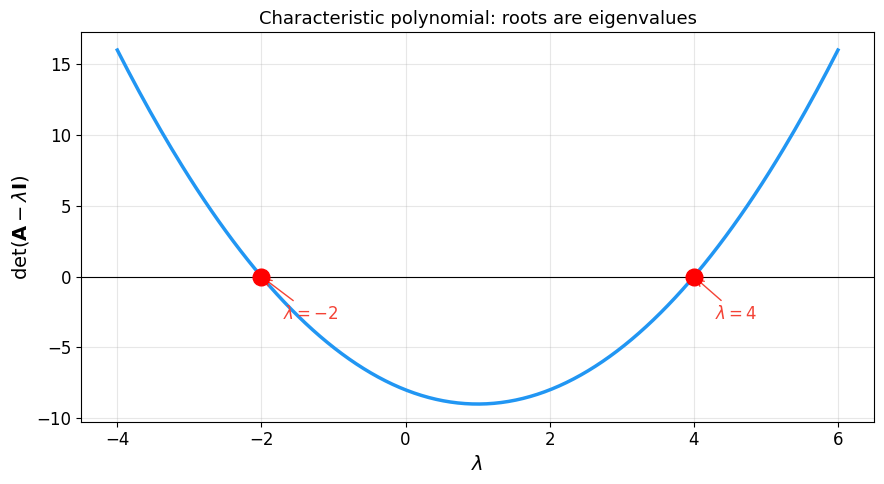

Figure saved.


In [23]:
A = np.array([[1, 3], [3, 1]])

# Plot det(A - lambda*I) as a function of lambda
lam_range = np.linspace(-4, 6, 200)
det_vals = [np.linalg.det(A - l * np.eye(2)) for l in lam_range]

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(lam_range, det_vals, '#2196F3', lw=2.5)
ax.axhline(0, color='k', lw=0.8)

# Mark eigenvalues (where det = 0)
eigvals = np.linalg.eigvals(A)
for ev in eigvals:
    ax.plot(ev, 0, 'ro', ms=12, zorder=5)
    ax.annotate(f'$\\lambda = {ev:.0f}$', xy=(ev, 0), xytext=(ev+0.3, -3),
               fontsize=12, color='#F44336',
               arrowprops=dict(arrowstyle='->', color='#F44336'))

ax.set_xlabel('$\\lambda$', fontsize=14)
ax.set_ylabel('$\\det(\\mathbf{A} - \\lambda\\mathbf{I})$', fontsize=14)
ax.set_title('Characteristic polynomial: roots are eigenvalues', fontsize=13)
plt.tight_layout()
plt.savefig('fig_char_poly.png', dpi=100, bbox_inches='tight')
plt.show()
print('Figure saved.')

The characteristic polynomial $\det(\mathbf{A} - \lambda\mathbf{I}) = \lambda^2 - 2\lambda - 8$ is a parabola. Its roots (where the curve crosses zero) are the eigenvalues $\lambda = -2$ and $\lambda = 4$.

For a $3 \times 3$ matrix, this would be a cubic curve with three roots; for an $M \times M$ matrix, a degree-$M$ polynomial with $M$ roots (some possibly complex). This directly connects linear algebra to the **Fundamental Theorem of Algebra**: every square matrix has exactly $M$ eigenvalues (counted with multiplicity).

**Cross-chapter preview:** In Chapter 13, we will compute eigenvalues and eigenvectors simultaneously using `np.linalg.eig()`, which internally uses iterative algorithms (QR iteration) rather than explicitly solving the characteristic polynomial.

## 6. Application: Is a Vector in the Column Space?

A key application of rank: determine whether $\mathbf{v} \in \mathcal{C}(\mathbf{A})$ by the **augmentation test**:

1. Form the augmented matrix $\tilde{\mathbf{A}} = [\mathbf{A} \;|\; \mathbf{v}]$
2. Compare ranks: $\text{rank}(\tilde{\mathbf{A}})$ vs. $\text{rank}(\mathbf{A})$
3. If equal: $\mathbf{v} \in \mathcal{C}(\mathbf{A})$ (the vector is redundant -- already reachable). If rank increased: $\mathbf{v} \notin \mathcal{C}(\mathbf{A})$ (new information added).

In [24]:
# Matrix with rank 2 and two test vectors
A = np.array([[1, 2],
              [3, 1],
              [5, 0]])

# v1 is in C(A): it's 2*col1 + 1*col2
v1 = 2 * A[:, 0] + 1 * A[:, 1]

# v2 is NOT in C(A)
v2 = np.array([0, 0, 1])

print(f'A =\n{A}')
print(f'rank(A) = {np.linalg.matrix_rank(A)}\n')

for name, v in [('v1 (in C(A))', v1), ('v2 (not in C(A))', v2)]:
    A_aug = np.column_stack([A, v])
    r_A = np.linalg.matrix_rank(A)
    r_aug = np.linalg.matrix_rank(A_aug)
    in_colspace = r_A == r_aug
    print(f'{name}: v = {v}')
    print(f'  rank(A) = {r_A}, rank([A|v]) = {r_aug}')
    print(f'  v in C(A)? {"YES" if in_colspace else "NO"}')
    print()

A =
[[1 2]
 [3 1]
 [5 0]]
rank(A) = 2

v1 (in C(A)): v = [ 4  7 10]
  rank(A) = 2, rank([A|v]) = 2
  v in C(A)? YES

v2 (not in C(A)): v = [0 0 1]
  rank(A) = 2, rank([A|v]) = 3
  v in C(A)? NO



The augmentation test confirms:

- $\mathbf{v}_1 = 2\mathbf{a}_1 + 1\mathbf{a}_2$ is in the column space -- augmenting does not increase the rank (the vector is redundant).
- $\mathbf{v}_2 = [0, 0, 1]^T$ is *not* in the column space -- augmenting increases the rank by $1$ (the vector adds new information).

**Data science connection:** This is the logic behind least squares fitting. The observed data vector $\mathbf{y}$ is almost never in $\mathcal{C}(\mathbf{X})$ (the design matrix's column space), because real data has noise. Instead, we find the *closest* point in $\mathcal{C}(\mathbf{X})$ to $\mathbf{y}$ -- the orthogonal projection. This is exactly the least squares solution $\hat{\mathbf{y}} = \mathbf{X}(\mathbf{X}^T\mathbf{X})^{-1}\mathbf{X}^T\mathbf{y}$ (Chapter 11).

## 7. Chapter Summary

This chapter introduced the concepts that transform matrices from simple arrays of numbers into powerful structures with deep mathematical meaning.

**Matrix norms** provide scalar summaries of matrix "size." The **Frobenius norm** $\|\mathbf{A}\|_F = \sqrt{\sum a_{ij}^2} = \sqrt{\text{tr}(\mathbf{A}^T\mathbf{A})}$ is the most common, used in regularisation ($\ell_2$: ridge, $\ell_1$: lasso) and matrix distance.

**The trace** $\text{tr}(\mathbf{A}) = \sum a_{ii}$ is the sum of diagonal elements. It equals the sum of eigenvalues and connects to the Frobenius norm.

**Matrix spaces** define what a matrix can "reach":

- Column space $\mathcal{C}(\mathbf{A})$: all vectors $\mathbf{b}$ satisfying $\mathbf{A}\mathbf{x} = \mathbf{b}$ for some $\mathbf{x}$
- Row space $\mathcal{R}(\mathbf{A}) = \mathcal{C}(\mathbf{A}^T)$: all linear combinations of rows
- Null space $\mathcal{N}(\mathbf{A})$: all $\mathbf{y}$ satisfying $\mathbf{A}\mathbf{y} = \mathbf{0}$ (the "invisible" directions)

**Rank** quantifies independent information: $r = $ number of linearly independent columns $= \dim(\mathcal{C}(\mathbf{A})) = \dim(\mathcal{R}(\mathbf{A}))$. Full rank means invertible; rank-deficient means singular. Shifting ($\mathbf{A} + \lambda\mathbf{I}$) restores full rank with minimal information change.

**The determinant** $\det(\mathbf{A})$ is zero for singular matrices and nonzero for full-rank matrices. It is defined only for square matrices and is computed as $ad - bc$ for $2 \times 2$ matrices.

**The characteristic polynomial** $\det(\mathbf{A} - \lambda\mathbf{I}) = 0$ connects all of these concepts. Its roots are the **eigenvalues** of $\mathbf{A}$, and the null spaces of the shifted matrices are the **eigenvectors**. This is the bridge to Chapter 13.